# Quantized YOLO Inference
Load the trained quantized model and visualize bounding box predictions on validation images.

In [1]:
import os, glob, time
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from nets.tinysimov35_keras_quantized_functional import yolo_v8_s_quantized_functional
from nets.tinysimov35_keras_functional import decode_predictions
from utils.util_keras import non_max_suppression, scale

%matplotlib inline

2026-02-16 20:07:04.925947: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-16 20:07:04.982557: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-16 20:07:04.982604: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-16 20:07:04.984176: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-16 20:07:04.992853: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-16 20:07:04.993710: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
# ── Config ──────────────────────────────────────────────
WEIGHTS   = "results/bac/quantized_integration_from_pretrained/best.weights.h5"
IMG_DIR   = "Dataset/bionano_cellv2/images/val"
LABEL_DIR = "Dataset/bionano_cellv2/labels/val"
IMG_SIZE  = (128, 256)          # (H, W) – must match training
NUM_CLS   = 1
CLASS_NAMES = {0: "cell"}
CONF_THR  = 0.25
IOU_THR   = 0.45

In [3]:
# ── Build model & load weights ──────────────────────────
model = yolo_v8_s_quantized_functional(NUM_CLS, img_size=IMG_SIZE)
model.load_weights(WEIGHTS)
print(f"Loaded weights from {WEIGHTS}")
model.summary()

2026-02-16 20:07:11.698204: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_COMPAT_NOT_SUPPORTED_ON_DEVICE: forward compatibility was attempted on non supported HW
2026-02-16 20:07:11.698270: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:129] retrieving CUDA diagnostic information for host: mdi220
2026-02-16 20:07:11.698290: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:136] hostname: mdi220
2026-02-16 20:07:11.698448: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:159] libcuda reported version is: 580.126.9
2026-02-16 20:07:11.698508: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] kernel reported version is: 580.95.5
2026-02-16 20:07:11.698526: E external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:244] kernel version 580.95.5 does not match DSO version 580.126.9 -- cannot find working devices in this configuration


Loaded weights from results/bac/quantized_integration_from_pretrained/best.weights.h5
Model: "yolo_quantized_functional"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, 128, 256, 3)]        0         []                            
                                                                                                  
 backbone_qconv1 (QConv2D)   (None, 64, 128, 4)           108       ['input[0][0]']               
                                                                                                  
 backbone_bn1 (BatchNormali  (None, 64, 128, 4)           16        ['backbone_qconv1[0][0]']     
 zation)                                                                                          
                                                                                       

/home/mdi220/.virtualenvs/yolo_py311/lib/python3.11/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


In [4]:
# ── Preprocessing helper ────────────────────────────────
def preprocess(img_bgr, target_hw):
    """Resize with letterbox padding, return (tensor, ratio, (pad_w, pad_h), orig_hw)."""
    th, tw = target_hw
    h, w = img_bgr.shape[:2]
    r = min(th / h, tw / w)
    r = min(r, 1.0)                       # don't upscale
    new_h, new_w = int(round(h * r)), int(round(w * r))
    if (h, w) != (new_h, new_w):
        img_bgr = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    pad_h = th - new_h
    pad_w = tw - new_w
    top, bottom = pad_h // 2, pad_h - pad_h // 2
    left, right = pad_w // 2, pad_w - pad_w // 2
    img_bgr = cv2.copyMakeBorder(img_bgr, top, bottom, left, right,
                                  cv2.BORDER_CONSTANT, value=(0, 0, 0))
    # BGR → RGB, float32, NHWC
    img_rgb = img_bgr[..., ::-1].astype(np.float32) / 255.0
    tensor = tf.constant(img_rgb[None], dtype=tf.float32)
    return tensor, (r, r), (left, top), (h, w)

In [5]:
# ── Inference + drawing on a single image ───────────────
def run_inference(img_path, model, conf_thr=CONF_THR, iou_thr=IOU_THR):
    """Return (original_rgb, detections_xyxy_conf_cls)."""
    img_bgr = cv2.imread(img_path)
    orig_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    tensor, ratio, (pw, pt), (oh, ow) = preprocess(img_bgr, IMG_SIZE)

    # Forward pass
    raw = model(tensor, training=False)          # (1, H', W', 65)
    decoded = decode_predictions(raw, model.stride, model.nc, model.dfl_ch)
    dets = non_max_suppression(decoded, conf_thr, iou_thr)  # list of (N,6)

    det = dets[0]
    if det is not None and len(det) > 0:
        det_np = det.numpy().copy()
        # Scale boxes back to original image coords
        ratio_pad = [[ratio[0], ratio[1]], [pw, pt]]
        scale(det_np[:, :4], tensor.shape[1:3], (oh, ow), ratio_pad)
        return orig_rgb, det_np
    return orig_rgb, np.zeros((0, 6))


def load_gt_boxes(img_path, oh, ow):
    """Load YOLO-format GT labels for an image → list of (cls, x1, y1, x2, y2)."""
    base = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(LABEL_DIR, base + ".txt")
    if not os.path.isfile(lbl_path):
        return []
    boxes = []
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls, xc, yc, w, h = int(parts[0]), *map(float, parts[1:])
            x1 = (xc - w / 2) * ow
            y1 = (yc - h / 2) * oh
            x2 = (xc + w / 2) * ow
            y2 = (yc + h / 2) * oh
            boxes.append((cls, x1, y1, x2, y2))
    return boxes

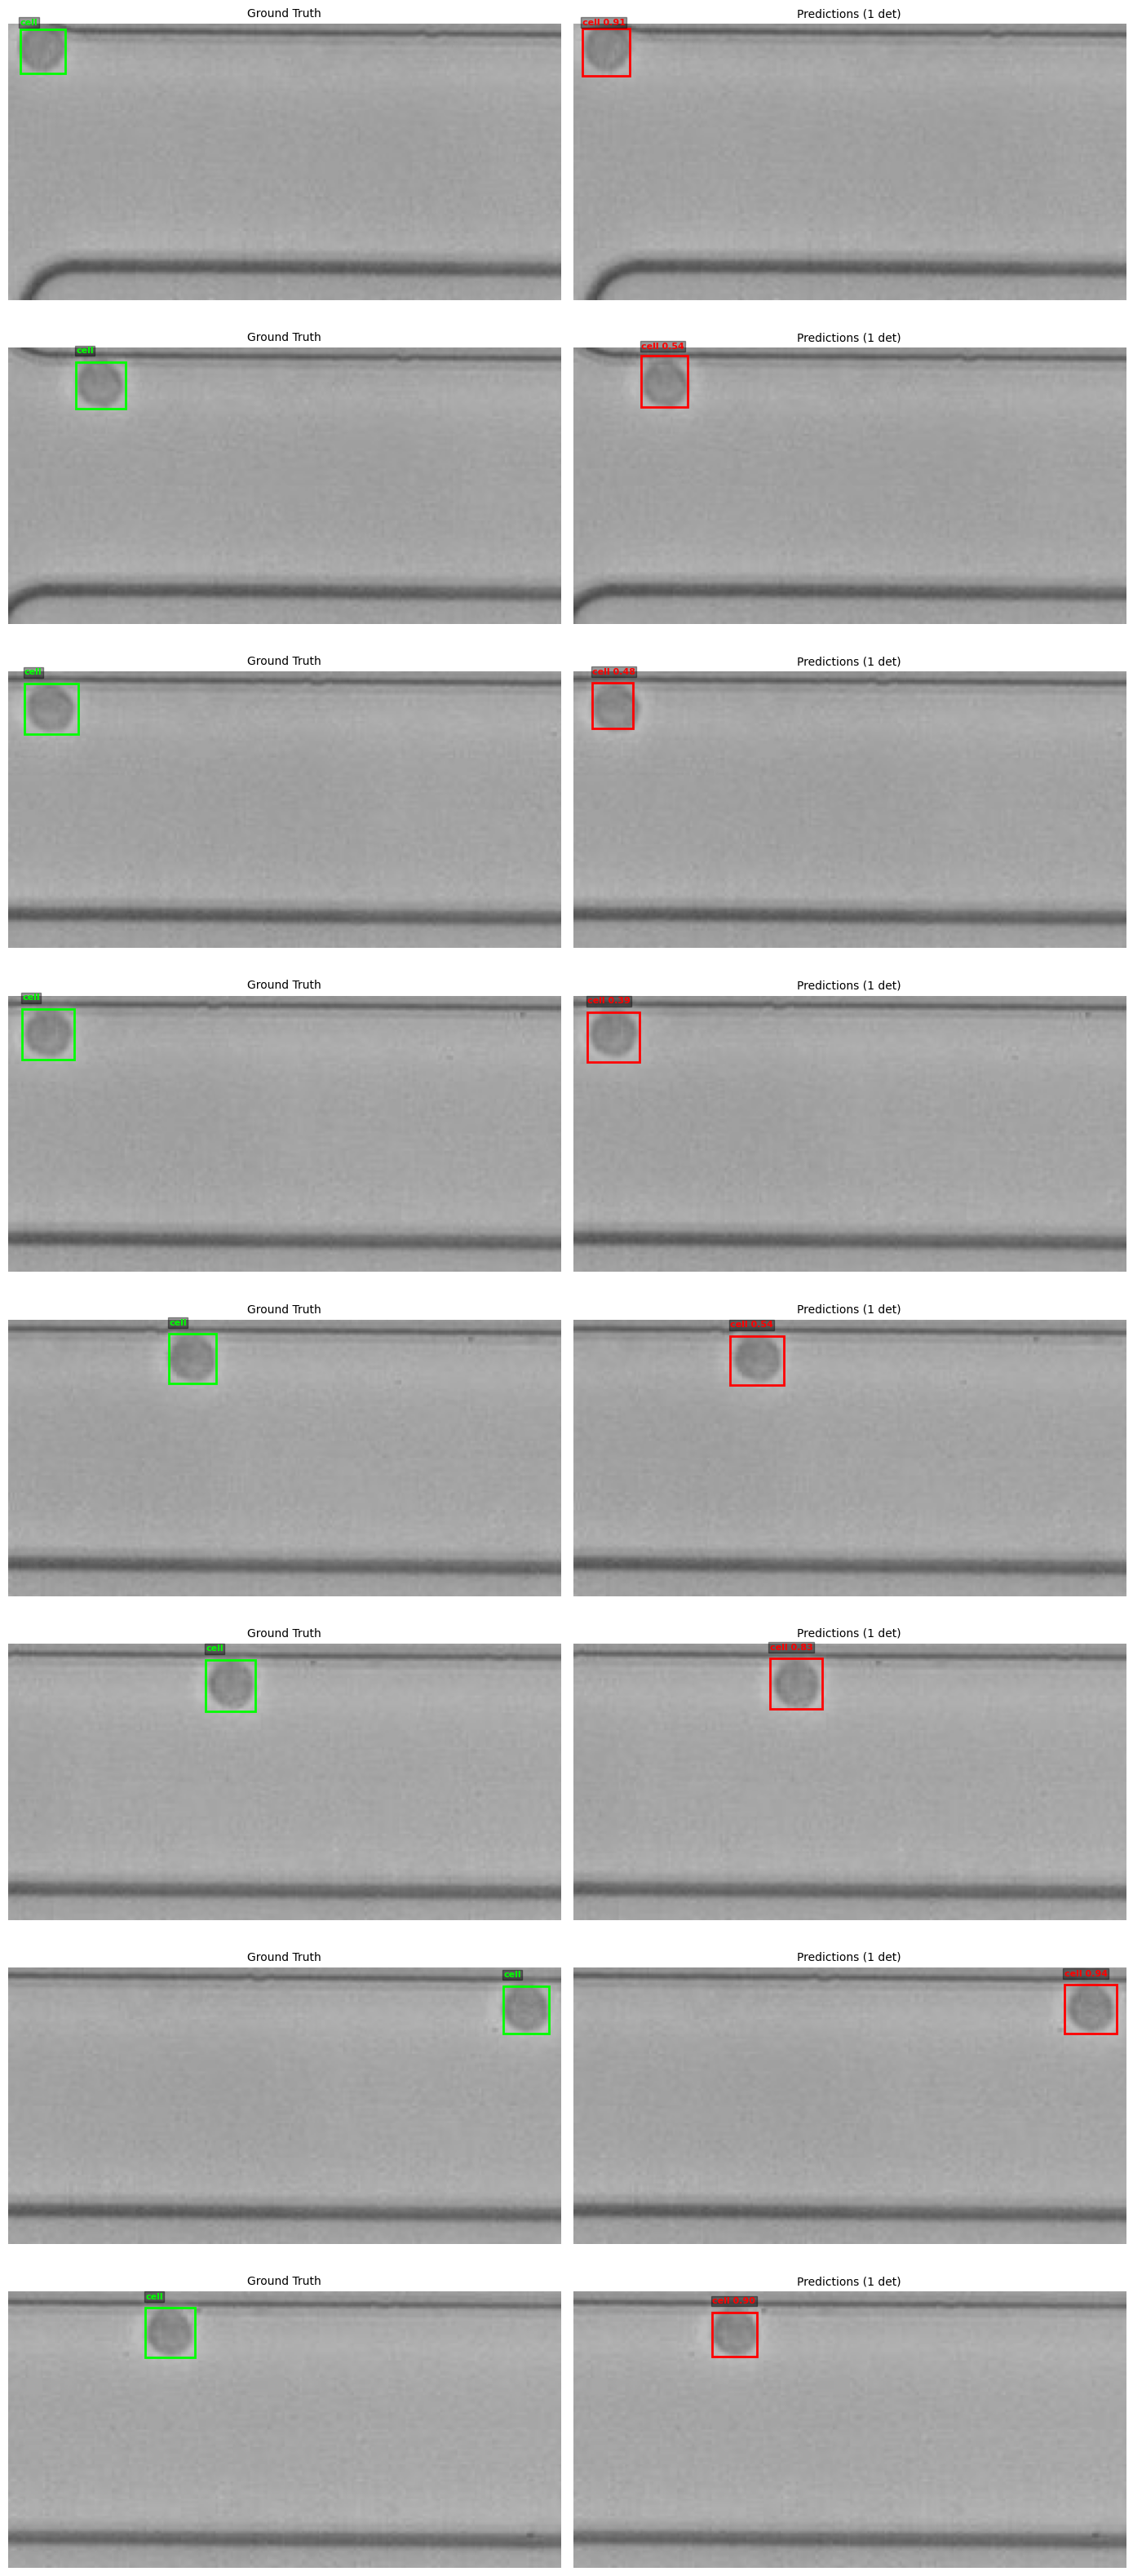

In [6]:
# ── Run on validation images ────────────────────────────
image_paths = sorted(glob.glob(os.path.join(IMG_DIR, "*.jpg")))
N_SHOW = min(8, len(image_paths))           # how many images to display

fig, axes = plt.subplots(N_SHOW, 2, figsize=(14, 4 * N_SHOW))
if N_SHOW == 1:
    axes = axes[None, :]

for idx in range(N_SHOW):
    img_path = image_paths[idx]
    orig_rgb, dets = run_inference(img_path, model)
    oh, ow = orig_rgb.shape[:2]
    gt_boxes = load_gt_boxes(img_path, oh, ow)

    # ---- Ground Truth (left) ----
    ax_gt = axes[idx, 0]
    ax_gt.imshow(orig_rgb)
    for cls, x1, y1, x2, y2 in gt_boxes:
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor="lime", facecolor="none")
        ax_gt.add_patch(rect)
        ax_gt.text(x1, max(y1 - 4, 0), CLASS_NAMES.get(cls, str(cls)),
                   color="lime", fontsize=8, weight="bold",
                   bbox=dict(facecolor="black", alpha=0.4, pad=1))
    ax_gt.set_title("Ground Truth", fontsize=10)
    ax_gt.axis("off")

    # ---- Predictions (right) ----
    ax_pr = axes[idx, 1]
    ax_pr.imshow(orig_rgb)
    for d in dets:
        x1, y1, x2, y2, conf, cls_id = d
        cls_id = int(cls_id)
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor="red", facecolor="none")
        ax_pr.add_patch(rect)
        label = f"{CLASS_NAMES.get(cls_id, str(cls_id))} {conf:.2f}"
        ax_pr.text(x1, max(y1 - 4, 0), label,
                   color="red", fontsize=8, weight="bold",
                   bbox=dict(facecolor="black", alpha=0.4, pad=1))
    ax_pr.set_title(f"Predictions ({len(dets)} det)", fontsize=10)
    ax_pr.axis("off")

plt.tight_layout()
plt.show()

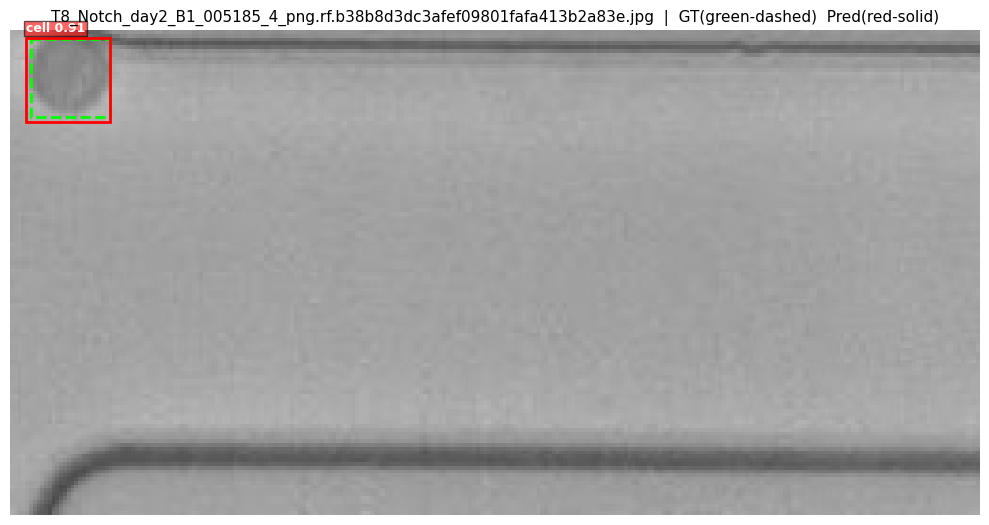

Detections (1):
    cell  conf=0.912  box=[4,2,26,24]


In [ ]:
# ── Single-image detailed view (pick any index) ────────
PICK = 0
img_path = image_paths[PICK]
orig_rgb, dets = run_inference(img_path, model)
oh, ow = orig_rgb.shape[:2]
gt_boxes = load_gt_boxes(img_path, oh, ow)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.imshow(orig_rgb)

# GT in green
for cls, x1, y1, x2, y2 in gt_boxes:
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              linewidth=2, edgecolor="lime", facecolor="none", linestyle="--")
    ax.add_patch(rect)

# Predictions in red
for d in dets:
    x1, y1, x2, y2, conf, cls_id = d
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                              linewidth=2, edgecolor="red", facecolor="none")
    ax.add_patch(rect)
    ax.text(x1, max(y1 - 4, 0),
            f"{CLASS_NAMES.get(int(cls_id), str(int(cls_id)))} {conf:.2f}",
            color="white", fontsize=9, weight="bold",
            bbox=dict(facecolor="red", alpha=0.6, pad=1))

ax.set_title(f"{os.path.basename(img_path)}  |  GT(green-dashed)  Pred(red-solid)", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Detections ({len(dets)}):")
for d in dets:
    x1, y1, x2, y2, conf, cls_id = d
    print(f"  {CLASS_NAMES.get(int(cls_id), int(cls_id)):>6s}  conf={conf:.3f}  box=[{x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f}]")